# Chung et al. (2017) – Single-cell RNA-seq enables comprehensive tumour and immune cell profiling in primary breast cancer

The original paper can be found here: https://www.nature.com/articles/ncomms15081

__Abstract__: Single-cell transcriptome profiling of tumour tissue isolates allows the characterization of heterogeneous tumour cells along with neighbouring stromal and immune cells. Here we adopt this powerful approach to breast cancer and analyse 515 cells from 11 patients. Inferred copy number variations from the single-cell RNA-seq data separate carcinoma cells from non-cancer cells. At a single-cell resolution, carcinoma cells display common signatures within the tumour as well as intratumoral heterogeneity regarding breast cancer subtype and crucial cancer-related pathways. Most of the non-cancer cells are immune cells, with three distinct clusters of T lymphocytes, B lymphocytes and macrophages. T lymphocytes and macrophages both display immunosuppressive characteristics: T cells with a regulatory or an exhausted phenotype and macrophages with an M2 phenotype. These results illustrate that the breast cancer transcriptome has a wide range of intratumoral heterogeneity, which is shaped by the tumour cells and immune cells in the surrounding microenvironment.

Chung et al. profile ~515 single cells from 11 primary breast tumors (plus 2 lymph-node mets). Labels encode cell states/types within cancer across patients/subtypes.

Data can be found here:
- https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE75688
- https://ftp.ncbi.nlm.nih.gov/geo/series/GSE75nnn/GSE75688/suppl/GSE75688_GEO_processed_Breast_Cancer_raw_TPM_matrix.txt.gz
- https://ftp.ncbi.nlm.nih.gov/geo/series/GSE75nnn/GSE75688/suppl/GSE75688_final_sample_information.txt.gz

## 0. Imports & Set-Up:

In [1]:
# add Leiden!

from sklearn.cluster import AgglomerativeClustering, KMeans, SpectralClustering
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import pairwise_distances, adjusted_rand_score
from sklearn.preprocessing import FunctionTransformer

import umap
from umap import UMAP

import numpy as np
import pandas as pd

import scanpy as sc
import anndata as ad, io, gzip, os

import matplotlib.pyplot as plt

from carve import CARVE
from carve.config import ValidatorConfig

In [2]:
%env PYTHONWARNINGS=ignore::FutureWarning,ignore::DeprecationWarning,ignore::UserWarning,ignore::RuntimeWarning

env: PYTHONWARNINGS=ignore::FutureWarning,ignore::DeprecationWarning,ignore::UserWarning,ignore::RuntimeWarning


---

## 1. Pre-Process the Data

In [3]:
dir = '../data/Chung/'

expr = pd.read_csv(f"{dir}Breast Cancer TPM Matrix.txt", sep="\t", index_col=0,)
meta = pd.read_csv(f"{dir}GSE75688 Final Sample Information.txt", sep="\t", index_col=0)

if expr.shape[0] > expr.shape[1]:  # if genes > cells we transpose
    expr = expr.T

# align metadata to cells
common = expr.index.intersection(meta.index)
adata = ad.AnnData(X=expr.loc[common].values.astype(np.float32))
adata.obs = meta.loc[common].copy()
adata.var.index = pd.Index(expr.columns, name="gene")

# store raw TPM and a log1p version for clustering
adata.layers["TPM"] = adata.X.copy()
# adata.X = np.log1p(adata.X)

print(adata.obs.columns.tolist())
adata

['type', 'index', 'index2', 'index3']


AnnData object with n_obs × n_vars = 527 × 57915
    obs: 'type', 'index', 'index2', 'index3'
    layers: 'TPM'

---

## 2. Analyse Data

In [4]:
print(f"np.unique(obs): {np.unique(adata.obs['type'].values)}")
print(f"len(np.unique(obs)): {len(np.unique(np.unique(adata.obs['type'].values)))}")

np.unique(obs): ['Bulk' 'SC']
len(np.unique(obs)): 2


In [5]:
print(f"np.unique(obs): {np.unique(adata.obs['index'].values)}")
print(f"len(np.unique(obs)): {len(np.unique(np.unique(adata.obs['index'].values)))}")

np.unique(obs): ['Tumor' 'nonTumor']
len(np.unique(obs)): 2


In [6]:
print(f"np.unique(obs): {np.unique(adata.obs['index2'].values)}")
print(f"len(np.unique(obs)): {len(np.unique(np.unique(adata.obs['index2'].values)))}")

np.unique(obs): ['Immune' 'Stromal' 'Tumor']
len(np.unique(obs)): 3


In [7]:
print(f"np.unique(obs): {np.unique(adata.obs['index3'].values)}")
print(f"len(np.unique(obs)): {len(np.unique(adata.obs['index3'].values))}")

np.unique(obs): ['Bcell' 'Immune' 'Myeloid' 'Stromal' 'Tcell' 'Tumor']
len(np.unique(obs)): 6


In [8]:
# construct X (cells x genes) and y from adata
X = pd.DataFrame(adata.X, index=adata.obs_names, columns=adata.var_names)
label_key = 'index3'
y = adata.obs[label_key].values

X.shape, y.shape

((527, 57915), (527,))

PCA plot of raw gene counts:

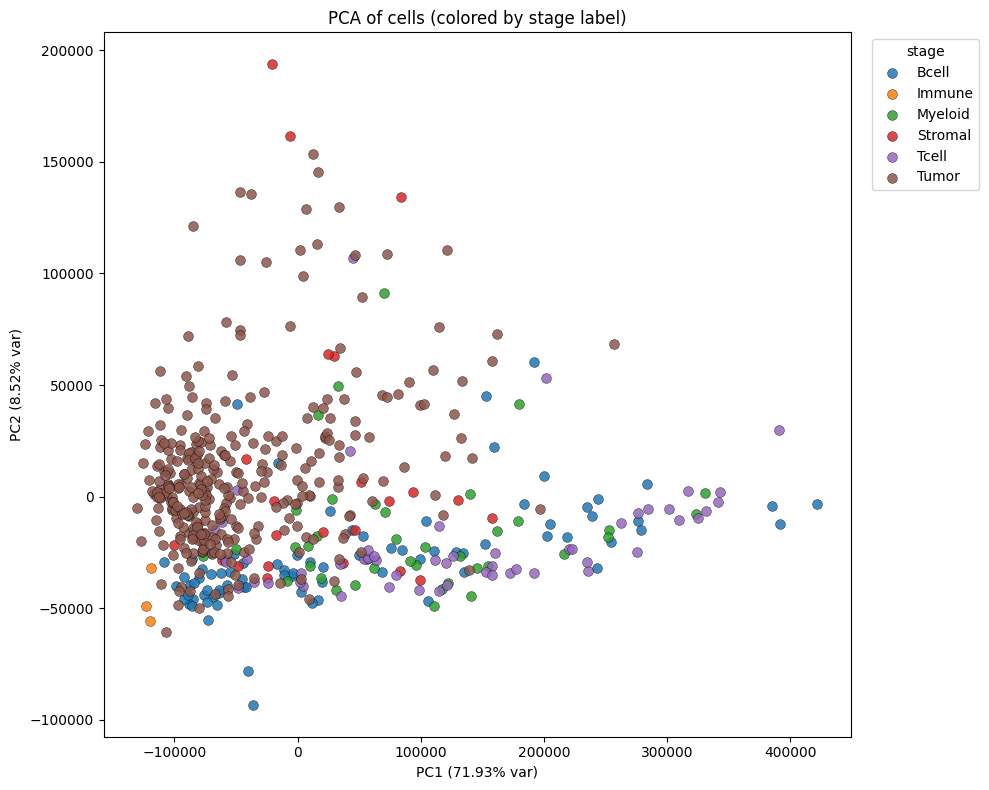

In [9]:
# PCA on cells (samples are columns of X) and scatter plot colored by y
pca = PCA(n_components=2)
pcs = pca.fit_transform(X)  # shape: (n_cells, 2)

pc_df = pd.DataFrame(pcs, index=X.index, columns=['PC1', 'PC2'])
pc_df['label'] = y

plt.figure(figsize=(10, 8))
labels = pd.Categorical(pc_df['label']).categories
cmap = plt.get_cmap('tab10')
color_map = {lab: cmap(i % 10) for i, lab in enumerate(labels)}

for lab in labels:
    sel = pc_df[pc_df['label'] == lab]
    plt.scatter(sel['PC1'], sel['PC2'], label=lab, color=color_map[lab], s=50, alpha=0.85, edgecolor='k', linewidth=0.3)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% var)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% var)")
plt.title("PCA of cells (colored by stage label)")
plt.legend(title='stage', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

Normalize and Select Highly-Variable Genes:

In [10]:
print(adata.obs.columns)

Index(['type', 'index', 'index2', 'index3'], dtype='object')


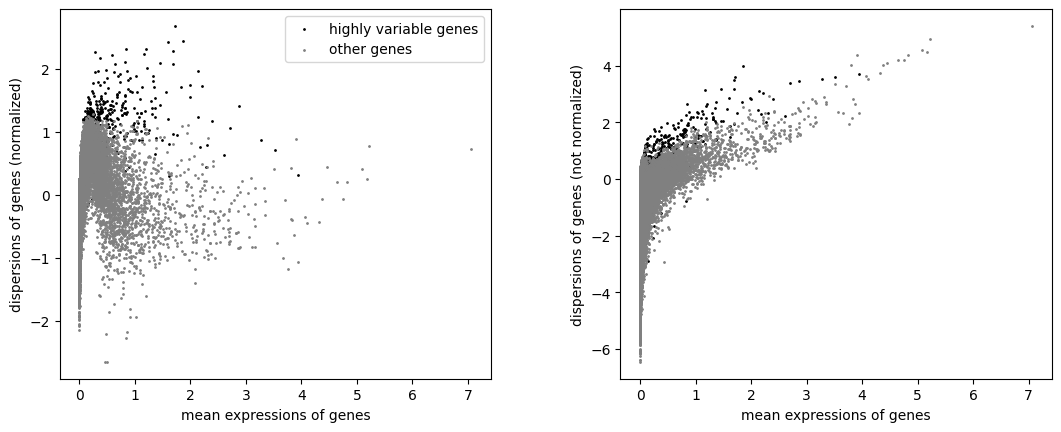

In [11]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=500, batch_key="index3", flavor='seurat')
sc.pl.highly_variable_genes(adata)

Subset to HVGs only:

In [12]:
adata = adata[:, adata.var["highly_variable"]].copy()

In [13]:
# # Overwrite X and y using the (HVG-subset) adata
X = pd.DataFrame(adata.X, index=adata.obs_names, columns=adata.var_names)

print("X.shape:", X.shape)
print("y.shape:", y.shape)

X.shape: (527, 500)
y.shape: (527,)


PCA of log1p transformed 500 HVGs:

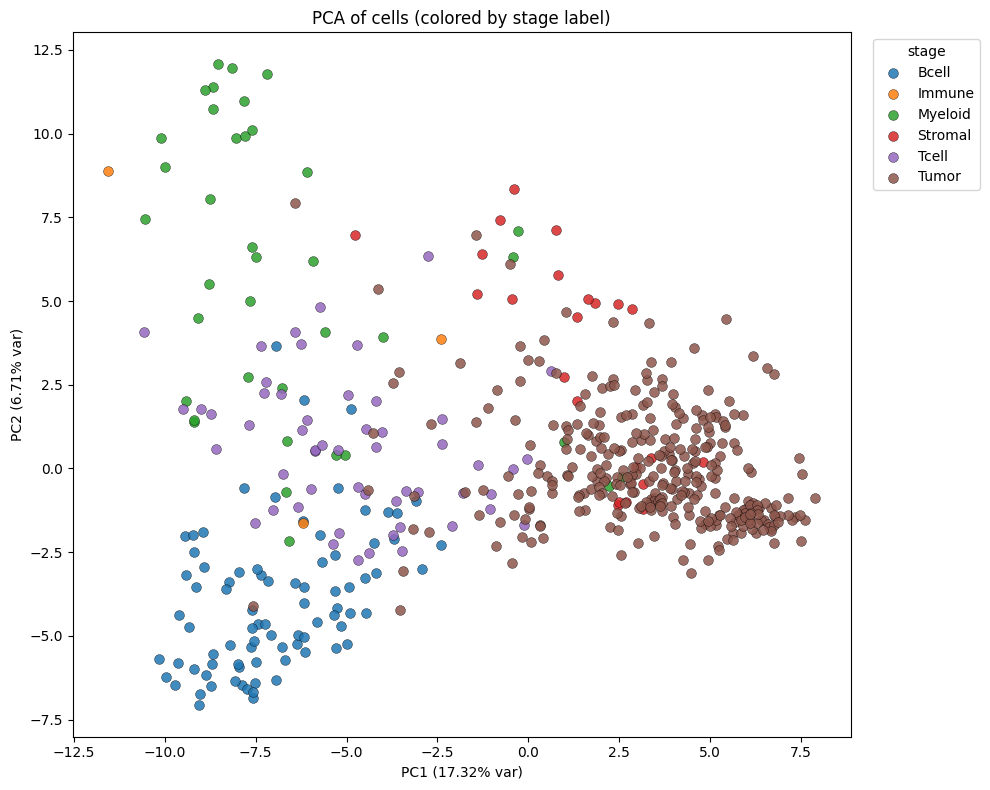

In [14]:
pca = PCA(n_components=2)
pcs = pca.fit_transform(X)

pc_df = pd.DataFrame(pcs, index=X.index, columns=['PC1', 'PC2'])
pc_df['label'] = y

plt.figure(figsize=(10, 8))
labels = pd.Categorical(pc_df['label']).categories
cmap = plt.get_cmap('tab10')
color_map = {lab: cmap(i % 10) for i, lab in enumerate(labels)}

for lab in labels:
    sel = pc_df[pc_df['label'] == lab]
    plt.scatter(sel['PC1'], sel['PC2'], label=lab, color=color_map[lab], s=50, alpha=0.85, edgecolor='k', linewidth=0.3)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% var)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% var)")
plt.title("PCA of cells (colored by stage label)")
plt.legend(title='stage', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

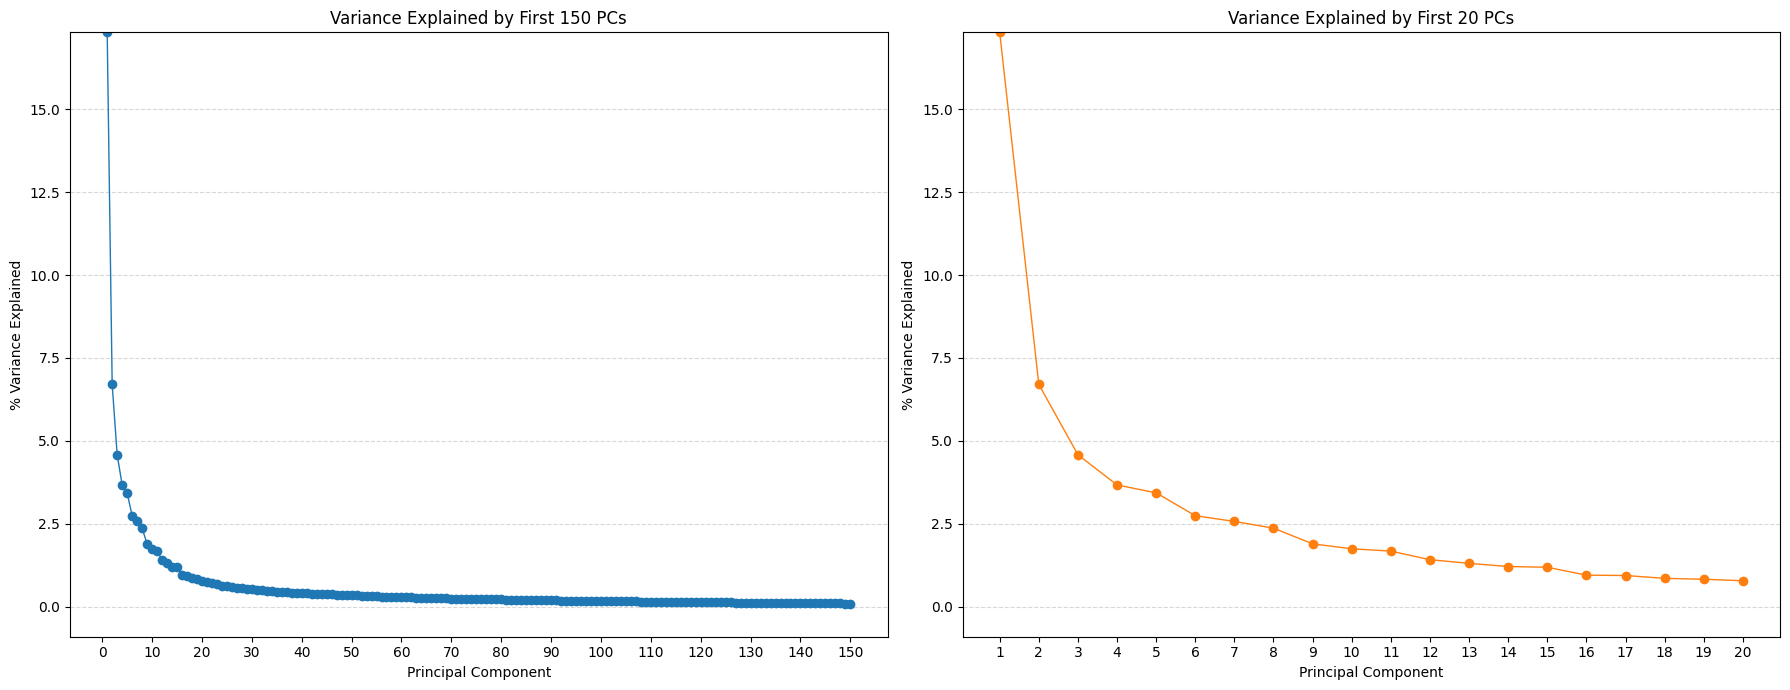

In [15]:
pca = PCA(n_components=150)
pcs = pca.fit_transform(X)

fig, ax = plt.subplots(1, 2, figsize=(18, 7))
ymin = min(pca.explained_variance_ratio_[:150] * 100).min() - 1
ymax = max(pca.explained_variance_ratio_[:150] * 100).max()
ax[0].set_ylim(ymin, ymax)
ax[1].set_ylim(ymin, ymax)

ax[0].plot(np.arange(1, 151), pca.explained_variance_ratio_[:150] * 100, marker='o', linewidth=1)
ax[0].set_xlabel('Principal Component')
ax[0].set_ylabel('% Variance Explained')
ax[0].set_title('Variance Explained by First 150 PCs')
ax[0].set_xticks(np.arange(0, 151, 10))
ax[0].grid(axis='y', linestyle='--', alpha=0.5)

ax[1].plot(np.arange(1, 21), pca.explained_variance_ratio_[:20] * 100, marker='o', linewidth=1, color='tab:orange')
ax[1].set_xlabel('Principal Component')
ax[1].set_ylabel('% Variance Explained')
ax[1].set_title('Variance Explained by First 20 PCs')
ax[1].set_xticks(np.arange(1, 21, 1))
ax[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Find largest drop in explained variance ratio between PCs ~12 and 20:

In [16]:
expl_var = pca.explained_variance_ratio_[:20] * 100
diffs = np.diff(expl_var)

drop_start = 12 - 1  # PC12 is index 11
drop_end = 20 - 1  # PC20 is index 19
drop_idx = np.argmin(diffs[drop_start:drop_end]) + drop_start

print(f"Largest drop between PC10 and PC20 is between PC{drop_idx+1} and PC{drop_idx+2}:")
print(f"Explained variance drops from {expl_var[drop_idx]:.2f}% to {expl_var[drop_idx+1]:.2f}% (Δ = {diffs[drop_idx]:.2f}%)")

Largest drop between PC10 and PC20 is between PC15 and PC16:
Explained variance drops from 1.19% to 0.95% (Δ = -0.24%)


In [17]:
explained_var_15 = pca.explained_variance_ratio_[:15].sum() * 100
print(f"Cumulative variance explained by the first 15 PCs: {explained_var_15:.2f}%")

Cumulative variance explained by the first 15 PCs: 53.86%


---

### Determine Pre-Processing Pipeline with CARVE:

In [19]:
norm_options = [
    (FunctionTransformer, {}), 
]

dr_options = [
    (PCA, 'pca_15', {
        'n_components': [15]
    }),
    (TSNE, {
        'n_components': [2], 
        'perplexity': list(range(5, 30+1))
    }),
    (UMAP, {
        'n_components': [2], 
        'n_neighbors': list(range(5, 15+1)), 
        'min_dist': [0.1]
    }),
]

cfg = ValidatorConfig(
    X=X,
    K=[5, 6, 7],
    B=100,
    norm_options=norm_options,
    dr_options=dr_options,
    ref_labels=y
)

val = CARVE(cfg)
val.validate(random_preprocess=True, random_state=42)

Grid configs:   0%|          | 0/27 [00:00<?, ?it/s]

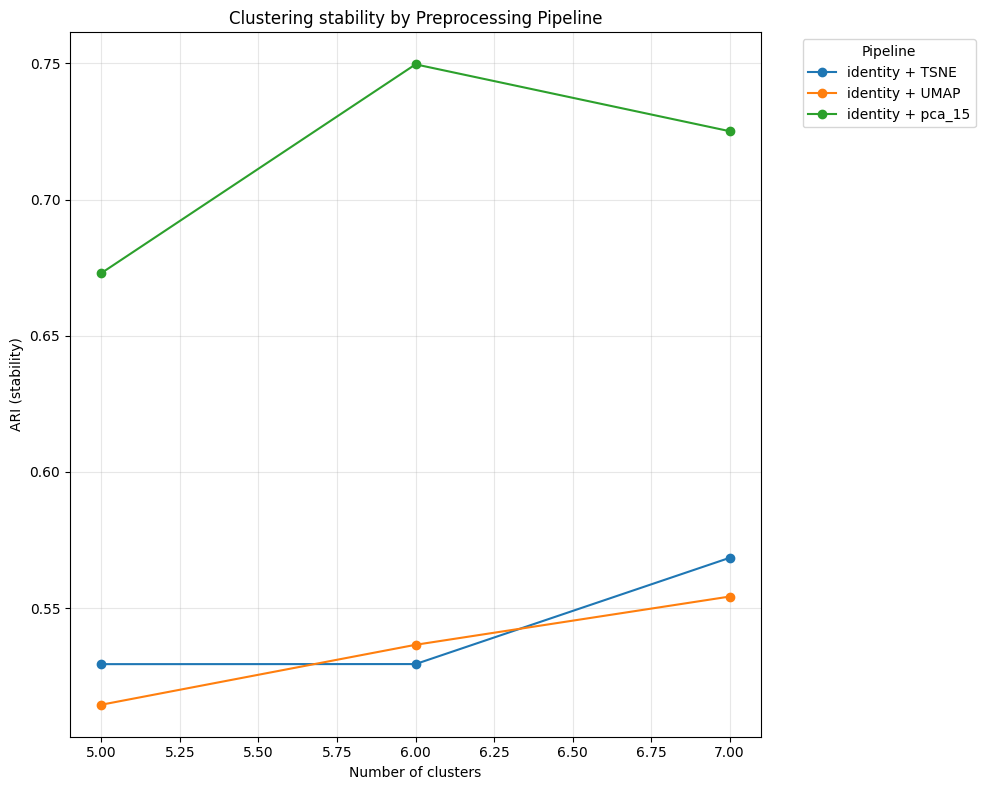

In [20]:
val.plot_preprocessing_results()

---
### Determine Optimal Clustering with CARVE:

In [59]:
pca = PCA(n_components=15)
X_log_pca = pca.fit_transform(X)
print("X_log_pca shape:", X_log_pca.shape)

X_log_pca shape: (527, 15)


In [61]:
cfg = ValidatorConfig(
    X=X_log_pca,
    K=10,
    B=100,
    ref_labels=y
)

val = CARVE(cfg)
val.validate(random_preprocess=False, random_state=42)

Grid configs:   0%|          | 0/81 [00:00<?, ?it/s]

In [62]:
val.plot_results(measure='s', rule='1se')

In [63]:
val.plot_results(measure='g', rule='1se')

/Users/kaiwycik/Documents/GitHub/ClusteringValidation/src/carve/_plotting.py:474: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



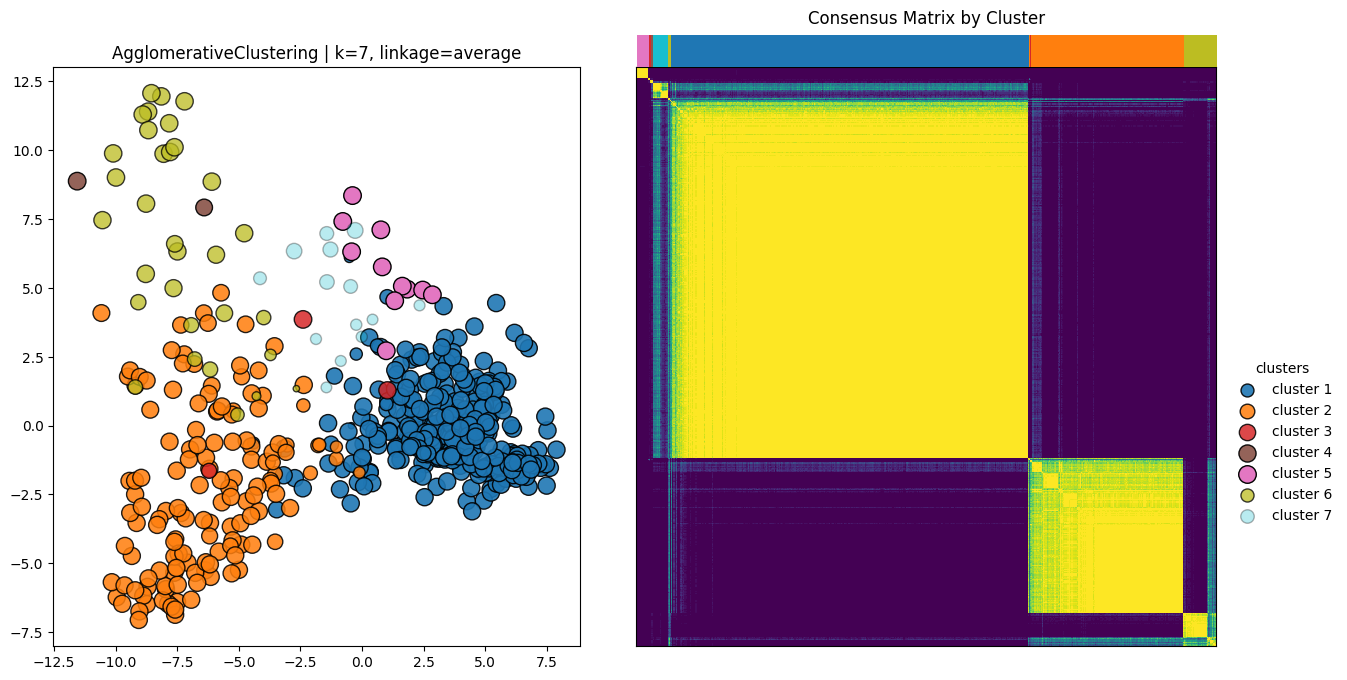

In [68]:
val.plot_consensus_clustering(k=7, figsize=(15, 8))

In [69]:
val.plot_clustering(k=7, measure='s', rule='1se')

FigureWidget({
    'data': [{'customdata': {'bdata': ('AAAAAAAAGEAAAAAAAAAAAAAAAAAAAP' ... 'CMamPS7j8AvD45uQLuPwAAAAAAAAAA'),
                             'dtype': 'f8',
                             'shape': '3, 6'},
              'hovertemplate': ('sample %{customdata[0]}<br>clu' ... 'tomdata[5]:.4f}<extra></extra>'),
              'legendgroup': 'cluster-0',
              'marker': {'color': '#636EFA',
                         'line': {'color': 'black', 'width': 1.0},
                         'opacity': 0.8463997761957549,
                         'size': {'bdata': 'yJKGGVjOKkBcaih10OgmQB9vY2pQUypA', 'dtype': 'f8'}},
              'mode': 'markers',
              'name': 'cluster 1',
              'showlegend': True,
              'type': 'scatter',
              'uid': '38909a44-3654-4619-b1e7-ad104a125017',
              'x': {'bdata': 'hTUZwCGTxsCV+oM/', 'dtype': 'f4'},
              'xaxis': 'x',
              'y': {'bdata': '5M12QM8Q0r+58qM/', 'dtype': 'f4'},
              'yaxi

In [70]:
agg = AgglomerativeClustering(n_clusters=7, linkage='average')
pred_labels = agg.fit_predict(X_log_pca)
ari = adjusted_rand_score(y, pred_labels)
print(f"ARI of AgglomerativeClustering (ward linkage) with true labels: {ari:.4f}")

ARI of AgglomerativeClustering (ward linkage) with true labels: 0.7426
